# Comparison between Insertion-Sort Counting-Sort

## Introduction
In this notebook I'm going to show, test and compare two different algorithmns: **insertion-sort** and **counting-sort**.
We'll evaluate both their performance time-wise but also memory-wise, and how they handle different types of random arrays.
The algorithmns will be sorting arrays of integers, since counting sort works only on natural numbers.

## Insertion-Sort
### Brief Overview

Insertion-sort works by splicing the array in two parts: one part that is always internally sorted and another which is comprised of yet to be sorted elements.
Each step the algorithmn takes a new element from the second part and **inserts** it in its correct placement in the sorted first part.



### Code

In [1]:
def insertion_sort(array):
    for j in range(len(array)):
        key = array[j]
        i = j - 1
        while i >= 0 and array[i] > key:
            array[i + 1] = array[i]
            i = i - 1
        array[i + 1] = key
    return array

### Example

In [2]:
test_input = [13, 24, 1, 5, 89, 20]
print(insertion_sort(test_input))

[1, 5, 13, 20, 24, 89]


### Performance
It works by sorting **in place**, so it doesn't require additional memory, and it has got a decent performance with few elements.
But time-wise it's quite inefficient as we had elements. In fact it has a time complexity of **O(n^2)**!

## Counting-Sort
### Brief Overview

Counting-sort is a sorting algorithmn that works in a peculiar way, it doesn't rely on direct comparisons between elements of the array.

The idea behind it is firstly to *count* how many time each element appears, then for each element i count how many numbers are equal to it or less, and lastly use this information to construct an array of the sorted elements of the input.

### Code

In [3]:
def counting_sort(input, k):
    support = [0] * (k + 1)
    output = [0] * len(input)
    
    for i in input:
        support[i] += 1
    for j in range(1, len(support)):
        support[j] += support[j -1]

    for i in reversed(input):
        output[support[i] - 1] = i
        support[i] -= 1
    return output

### Example

In [4]:
test_input = [8, 2, 3, 4, 0, 0, 5, 6, 8, 2, 7, 2, 4, 6, 10]
print(counting_sort(test_input, 10))

[0, 0, 2, 2, 2, 3, 4, 4, 5, 6, 6, 7, 8, 8, 10]


### Performance

#### Conditions

Counting-sort has some conditions that need to be met for it to work: 
1) Each element needs to be a non negative integer;
2) The upper bound (we'll call it k) must be known.

The upper bound can be known beforehand, but sometimes it's necessary to calculate it from scratch. Computing it adds an additional loop through all the items in the array to sort.

#### Memory Performance

Counting-sort **doesn't sort in place**, so it requires a support **array of length k**. This can be especially costly if the upper bound is quite high, but the number of actually different elements in the array is low.

For example if we had an input array \[2, 1, 300, 0] we'd have a support array of length 300 while we only really needed 4 elements.

To get around this problem we can use an hash table, letting us map the support array only to the possible values of the input array.
This can help memory usage in this specific case, but it'd require using an hash map also for cases don't really need it, leading to unecessary costs both time-wise and memory-wise.

#### Time Performance

Despite these limitations Counting-sort has an incredible time complexity of **O(n+k)**! This is possible because it's not a comparison based sort, so it can bypass the lower bound of n*logn.

But because its time complexity depends both on n, the number of elements, and k, the upper bound value of the possible elements, theoretically we can have a worst case scenario where k is equal to n squared, or even worse! So a high upper bound causes problems not only with memory but time too.

## Testing Experiments

### Completely Random Array, Small Upper Bound

testing completely random array, small upper bound
starting insertion-sort
starting counting-sort


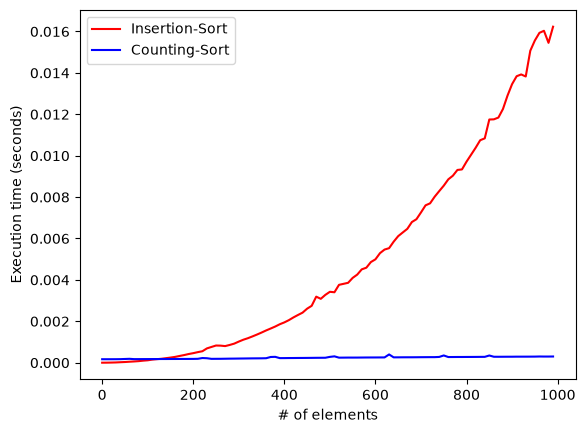

In [5]:
from math import inf
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import random

def test_insertion_sort(inputs, repeats, outputs, step):
    for i in range(0, len(inputs), step):
        best = inf
        for _ in range(repeats):
            start = timer()
            insertion_sort(inputs[:i])
            end = timer()
            best = min(best, end - start)
        time.append(best)

def test_counting_sort(inputs, k, repeats, outputs, step):
    for i in range(0, len(inputs), step):
        best = inf
        for _ in range(repeats):
            start = timer()
            counting_sort(inputs[:i], k)
            end = timer()
            best = min(best, end - start)
        time.append(best)
    

max_number_of_elements = 1000
step = 10
# the x coordinate of the graph
number_of_operation = range(0, max_number_of_elements, step)
# upper bound for the values in the list to sort
interval_end = 3000
# how many times each step of the test is run
number_of_repeats = 5
inputs = random.choices(range(interval_end), k=max_number_of_elements)

print("testing completely random array, small upper bound")

print("starting insertion-sort")
time = []
test_insertion_sort(inputs, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "r", label="Insertion-Sort")

print("starting counting-sort")
time = []
test_counting_sort(inputs, interval_end, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "b", label="Counting-Sort")

plt.xlabel("# of elements")
plt.ylabel("Execution time (seconds)")
plt.legend()
plt.show()

In this case it's clear that counting-sort is by far the more efficient algorithmn of the two when the number of elements gets sufficiently high (around more than 150). And we can also denote that counting-sort stays also relatively consistent in execution time; this makes sense when we consider that the upper bound of quite bigger than the maximum number of elements to sort.

### Completely Random Array, Medium Upper Bound

testing completely random array, medium upper bound
starting insertion-sort
starting counting-sort


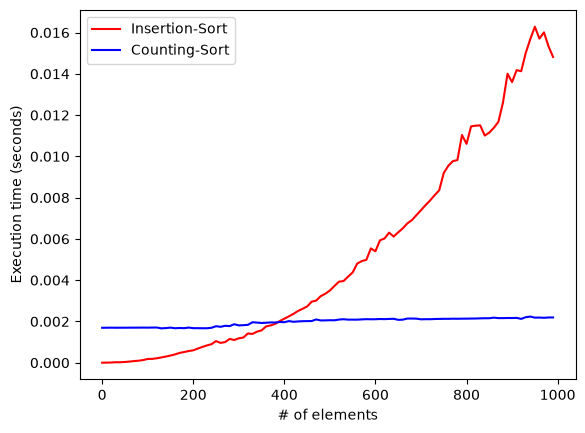

In [6]:
print("testing completely random array, medium upper bound")

interval_end = 30000
inputs = random.choices(range(interval_end), k=max_number_of_elements)

print("starting insertion-sort")
time = []
test_insertion_sort(inputs, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "r", label="Insertion-Sort")

print("starting counting-sort")
time = []
test_counting_sort(inputs, interval_end, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "b", label="Counting-Sort")

plt.xlabel("# of elements")
plt.ylabel("Execution time (seconds)")
plt.legend()
plt.show()

As we can see by increasing the upper bound the point where the two graphs meet has also increased. In this case it increased from ~150 to ~400. 

### Completely Random Array, High Upper Bound

testing with big interval of values
starting insertion-sort
starting counting-sort


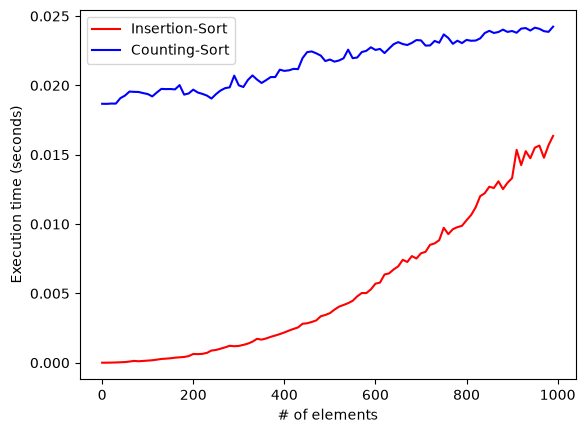

In [7]:
print("testing with big interval of values")

interval_end = 300000
inputs = random.choices(range(interval_end), k=max_number_of_elements)

print("starting insertion-sort")
time = []
test_insertion_sort(inputs, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "r", label="Insertion-Sort")

print("starting counting-sort")
time = []
test_counting_sort(inputs, interval_end, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "b", label="Counting-Sort")
plt.xlabel("# of elements")
plt.ylabel("Execution time (seconds)")
plt.legend()
plt.show()

This is clearly the worst case for counting-sort, 300'000 >> 1'000 and it shows in the performance.

### Already sorted array

testing on already sorted array
starting insertion-sort
starting counting-sort


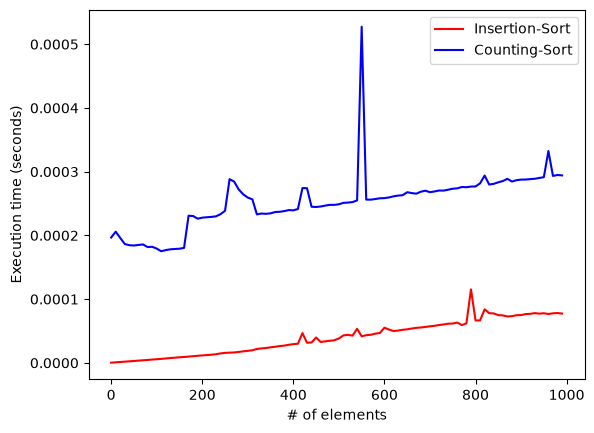

In [8]:
print("testing on already sorted array")

max_number_of_elements = 1000
interval_end = 3000
step = 10
number_of_operation = range(0, max_number_of_elements, step)
inputs = random.choices(range(interval_end), k=max_number_of_elements)
inputs.sort()

print("starting insertion-sort")
time = []
test_insertion_sort(inputs, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "r", label="Insertion-Sort")

print("starting counting-sort")
time = []
test_counting_sort(inputs, interval_end, number_of_repeats, time, step)
plt.plot(number_of_operation, time, "b", label="Counting-Sort")

plt.xlabel("# of elements")
plt.ylabel("Execution time (seconds)")
plt.legend()
plt.show()

Best case for inssertion-sort. The cost of insertion sort in this case is O(n) since it only requires insertions-sort to look through each item of the list once to confirm they're in the correct position.

## Conclusions